# Step 3: Model Training & Evaluation
**Placement Prediction & College Analytics Project**

In this notebook, we build and compare machine learning models for two tasks:
1. **Placement Status Classification**: Predict if a student will be placed (`Placed` = 1, `Not Placed` = 0) using **Logistic Regression**, **Decision Tree**, and **Random Forest** algorithms.
2. **Salary Package Regression**: Predict the expected salary (`package_lpa`) of placed students using **Linear Regression**.

## 1. Import Libraries and Load Data

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_absolute_error, mean_squared_error

# Load cleaned data
cleaned_path = '../data/cleaned/placement_data_cleaned.csv'
df = pd.read_csv(cleaned_path)
df.head()

,student_id,gender,age,degree,branch,cgpa,backlogs,internships,certifications,coding_skills,...,internship_status,certification_status,placement_status,package_lpa,company_name,has_internship,has_certification,total_skill_score,academic_performance_index,employability_score
0,1,Male,20,BE,Mechanical Engineering,8.40,2,2,2,1,...,Yes,Yes,Placed,8.18,Capgemini,1,1,8,74.0,10.560
1,2,Female,20,BTech,Electrical Engineering,8.60,2,0,5,1,...,No,Yes,Placed,8.41,Cognizant,0,1,7,76.0,6.240
2,3,Male,22,BCA,Electrical Engineering,6.62,3,0,1,1,...,No,Yes,Not Placed,0.00,Unplaced,0,1,8,51.2,5.848
3,4,Male,24,BCA,Data Science,8.01,0,0,4,4,...,No,Yes,Placed,8.69,Capgemini,0,1,13,80.1,8.404
4,5,Male,24,BCA,Electrical Engineering,9.12,2,1,2,4,...,Yes,Yes,Placed,12.08,Adobe,1,1,10,81.2,9.648


## 2. Define Features & Target Variables

In [2]:
# Input features
categorical_cols = ['gender', 'degree', 'branch']
numerical_cols = [
    'age', 'cgpa', 'backlogs', 'internships', 'certifications', 
    'coding_skills', 'communication_skills', 'project_count', 
    'has_internship', 'has_certification', 'total_skill_score', 
    'academic_performance_index', 'employability_score'
]

X = df[categorical_cols + numerical_cols]
# Classification target (1 = Placed, 0 = Not Placed)
y_clf = (df['placement_status'] == 'Placed').astype(int)

## 3. Placement Classifier Model Training & Comparison

In [3]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Preprocessor setup
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Dictionary of classification models
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

best_clf_name = None
best_clf_acc = 0.0
best_clf_pipeline = None

for name, clf in classifiers.items():
    # Build pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict & Evaluate
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Model: {name} | Test Accuracy: {acc:.4f}")
    
    if acc > best_clf_acc:
        best_clf_acc = acc
        best_clf_name = name
        best_clf_pipeline = pipeline

Train shape: (9600, 16), Test shape: (2400, 16)
Model: Logistic Regression | Test Accuracy: 0.9475
Model: Decision Tree | Test Accuracy: 0.9054
Model: Random Forest | Test Accuracy: 0.9383


### 3.1 Best Classification Model Evaluation

=== Best Model: Logistic Regression ===

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.77      0.58      0.66       213
      Placed       0.96      0.98      0.97      2187

    accuracy                           0.95      2400
   macro avg       0.87      0.78      0.82      2400
weighted avg       0.94      0.95      0.94      2400



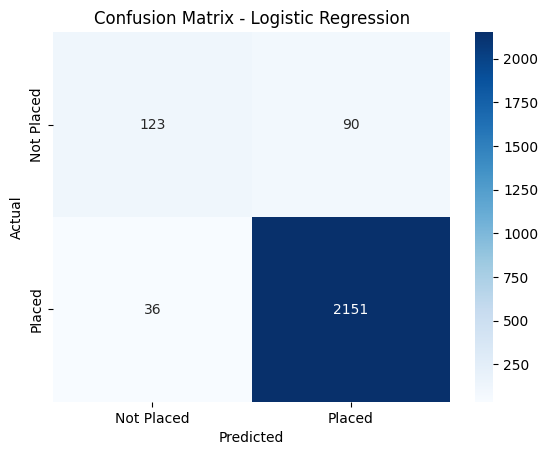

In [4]:
print(f"=== Best Model: {best_clf_name} ===")
y_pred = best_clf_pipeline.predict(X_test)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.title(f'Confusion Matrix - {best_clf_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3.2 Save Best Classifier Model

In [5]:
# Export the pipeline containing preprocessing and model
with open('../models/placement_model.pkl', 'wb') as f:
    pickle.dump(best_clf_pipeline, f)
print("Best placement classification model pipeline exported successfully.")

Best placement classification model pipeline exported successfully.


## 4. Salary Forecast Regressor (Linear Regression)

In [6]:
# Filter dataset for placed students only
placed_df = df[df['placement_status'] == 'Placed'].copy()
print(f"Number of records for salary regression: {len(placed_df)}")

X_reg = placed_df[categorical_cols + numerical_cols]
y_reg = placed_df['package_lpa']

# Split into training and testing sets
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Build regression pipeline
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train
reg_pipeline.fit(X_train_r, y_train_r)

# Predict & Evaluate
y_pred_r = reg_pipeline.predict(X_test_r)
r2 = r2_score(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print(f"Linear Regression Test R2 Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} LPA")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} LPA")

Number of records for salary regression: 10937
Linear Regression Test R2 Score: 0.9389
Mean Absolute Error (MAE): 0.47 LPA
Root Mean Squared Error (RMSE): 0.60 LPA


### 4.1 Actual vs Predicted Packages Plot

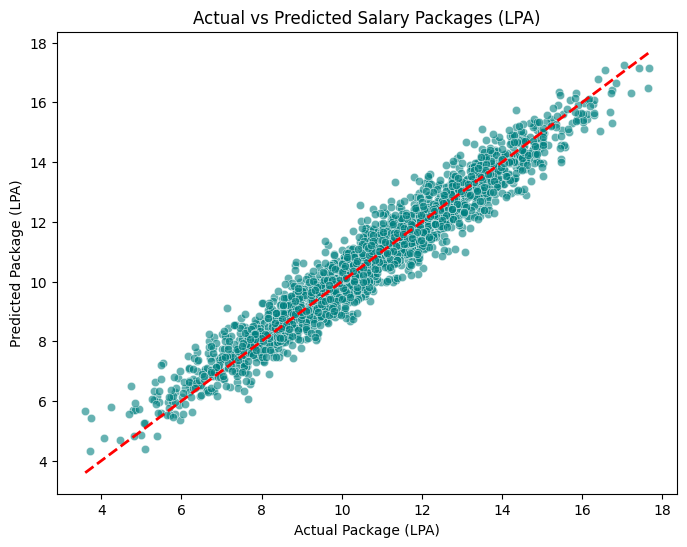

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.6, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Salary Packages (LPA)')
plt.xlabel('Actual Package (LPA)')
plt.ylabel('Predicted Package (LPA)')
plt.show()

### 4.2 Save Salary Regressor Model

In [8]:
# Export the regression pipeline
with open('../models/salary_model.pkl', 'wb') as f:
    pickle.dump(reg_pipeline, f)
print("Salary regression model pipeline exported successfully.")

Salary regression model pipeline exported successfully.
